1. off thresh in various regions makes them separable?
2. NR ON duration is bimodal? Wake vs real ON

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import ISRUtilities as isru
import xarray as xr
import scipy.stats as sps
import statsmodels.stats.multitest as smsm
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals_detection.batch'
do_save = False

In [ ]:
# old version which tries to correct for drift
def _infraSlowIntervalsDrift(session,threshold,regs=None):

    when = 'sleep.*#0'
    R = rg.data.Regions(session,phases=when)
    regs = R.ids if regs is None else np.array(regs)
    is_reg = np.isin(regs,R.ids)
    isr_dict = {r: np.full((1,2),np.nan) for r in regs[~is_reg]} # assign variables for not found regions
    isr_excl_dict = {r: np.full((1,2),np.nan) for r in regs[~is_reg]}
    on_dict = {r: np.full((1,2),np.nan) for r in regs[~is_reg]}
    regs = regs[np.isin(regs,R.ids)]

    units = np.array([len(R.units(regs=r)) for r in regs])
    fr = R.firingRate(regs=regs,window=0.05,step=5,smooth=70,norm=True)
    _, T, _ = R.avalanches(regs=regs,thresh=threshold[0],window=0.05,step=5,smooth=70)
    thresh = np.percentile(fr[:,1:],threshold,axis=0) # (threshold, region), absolute threshold from percentiles
    thresh[1] /= 4 # for min threshold, percentile(Ffr) / 4
    thresh = np.concatenate((thresh,np.full((1,len(regs)),np.nan))) # add extra line of thresholds in case drift is detected

    fraction = np.full(len(regs),np.nan)
    half_t = (R.eventIntervals().min() + R.eventIntervals().max()) / 2
    partitions = np.array([[0,1],[1,2]]) * half_t
    for i, r in enumerate(regs):

        # handle drift in region firing rate, assuming time domain is compact
        t_idx = T[r][:,0] > half_t # t_idx[i] indexes partition to which T[r][i] belongs
        drift_ratio = np.diff(T[r][t_idx]).sum() / np.diff(T[r][~t_idx]).sum()
        drift = drift_ratio < 0.1 or drift_ratio > 10
        if drift:
            print(f'drift detected in {R.basename} {r} {drift_ratio}')
            # rebuild T with two different thresholds
            this_T = []
            for j, p in enumerate(partitions):
                _, t, _ = R.avalanches(regs=r,when=p,thresh=threshold[0],window=0.05,step=5,smooth=70)
                this_T.append(t[r])
                thresh[j+1,i] = np.percentile(fma.general.restrict(fr[:,[0,i+1]],p)[:,1],threshold[1],axis=0)
            T[r] = np.concatenate(this_T)

        big = np.diff(T[r],axis=1).ravel() > 15 # 15 s, parameter to explore
        big[-1] = True # always exclude last avalanche to end last ISR epoch
        break_idx = np.where(big)[0]
        # ISR start and stop indexes
        start = np.insert(break_idx+1,0,0)
        stop = np.append(break_idx,len(big))
        valid = start != stop
        start = start[valid]
        stop = stop[valid]
        # putative ISR intervals
        isr = np.column_stack((T[r][start,0], T[r][stop,0])) # from onset of first ON to onset of discarded ON
        on = T[r][~big,:]
        isr_idx = np.cumsum(np.insert(~big[:-1] & big[1:],0,0))
        isr_idx = isr_idx[~big] # isr_idx[i] is idx of putative ISR interval containing i-th ON
        if drift:
            t_idx = (isr[:,0] > half_t).astype(int) # t_idx[i] indexes partition to which isr[i] belongs
        else:
            t_idx = np.zeros(len(isr),dtype=int)

        # search ISR intervals for min requirement
        valid = np.full(len(isr),False)
        if units[i] >= 15:
            fr_isr, fisr_idx = fma.general.restrict(fr[:,[0,i+1]],isr,i_ind=True)
            for j in range(len(isr)):
                this_fr = fr_isr[fisr_idx==j,1] # firing rate values in j-th putative ISR interval
                if len(this_fr) > 0:
                    valid[j] = np.percentile(this_fr,15) < thresh[t_idx[j]+1,i] # use threshold computed on the correct partition (if any)
        isr_dict[r] = isr[valid,:]
        isr_excl_dict[r] = isr[~valid,:]
        on_dict[r] = on[np.isin(isr_idx, np.where(valid)[0]),:]

        fraction[i] = np.diff(isr_dict[r],axis=1).sum() / np.diff(R.eventIntervals(),axis=1).sum()

    # exclude regions with too few neurons
    fraction[units<15] = np.nan

    fraction = xr.DataArray(fraction,dims='region',coords={'region': regs, 'rat': int(R.rat), 'base': R.basename})
    threshold = xr.DataArray(thresh,dims=['n','region'],coords={'region': regs, 'rat': int(R.rat)})
    units = xr.DataArray(units,dims='region',coords={'region': regs, 'rat': int(R.rat)})

    return fraction, isr_dict, on_dict, isr_excl_dict, fr, threshold, units

In [2]:
def _infraSlowIntervals(session,regs=None,anat=None,when='sleep.*#0',threshold=None,save=False):
    # note: outputs 'fr' and 'threshold' refer to last phase

    R = rg.data.Regions(session,phases=when,anat_file=anat)
    threshold = threshold[int(R.rat)] # extract thresholds from dict
    regs = R.ids if regs is None else np.asarray(regs)

    # assign variables
    is_reg = np.isin(regs,R.ids)
    isr_dict = {r: [np.zeros((0,2))] if is_reg[i] else [np.full((1,2),np.nan)] for i, r in enumerate(regs)}
    isr_excl_dict = {r: [np.zeros((0,2))] if is_reg[i] else [np.full((1,2),np.nan)] for i, r in enumerate(regs)}
    on_dict = {r: [np.zeros((0,2))] if is_reg[i] else [np.full((1,2),np.nan)] for i, r in enumerate(regs)}
    fraction = np.full(len(regs),np.nan)
    regs = regs[is_reg]
    units = np.array([len(R.units(regs=r)) for r in regs])
    thresh = np.full((len(threshold),len(regs)),np.nan)

    # detect ISA per session epoch
    when = R.eventIntervals()
    for k, phase in enumerate(when):

        # avalanches for this epoch
        _, T, _, fr = R.avalanches(regs=regs,when=phase,thresh=threshold[0],window=0.05,step=5,smooth=70,norm=True,return_fr=True)

        for i, r in enumerate(regs):

            # 1. validate number of units
            if units[i] < 15:
                continue

            thresh = np.percentile(fr[:,1:],threshold,axis=0) # (threshold, region), absolute threshold from percentiles
            thresh[1] /= 4 # for min threshold, percentile(fr) / 4
            thresh[2] /= 3 # for max threshold, percentile(fr) / 3
            half_t = phase.mean()

            # 2. detect drift in region firing rate
            t_idx = T[r][:,0] > half_t # t_idx[i] indexes partition to which T[r][i] belongs
            dur = np.diff(T[r]).ravel()
            t1 = dur[~t_idx].sum()
            drift_ratio = dur[t_idx].sum() / t1 if t1 != 0 else np.inf
            drift = np.diff(phase) > 6000 and (np.any(dur > np.diff(phase)*3/10) or drift_ratio < 0.1 or drift_ratio > 10)
            if drift:
                # flag region as invalid
                print(f'drift detected in {R.basename} {r}, phase {k} , drift ratio: {drift_ratio}')
                continue

            # 3. detect ISA
            big = np.diff(T[r],axis=1).ravel() > 15 # 15 s, parameter to explore
            big[-1] = True # always exclude last avalanche to end last ISR epoch
            break_idx = np.where(big)[0]
            # ISR start and stop indexes
            start = np.insert(break_idx+1,0,0)
            stop = np.append(break_idx,len(big))
            valid = start != stop
            start = start[valid]
            stop = stop[valid]
            # putative ISR intervals
            isr = np.column_stack((T[r][start,0], T[r][stop,0])) # from onset of first ON to onset of discarded ON
            on = T[r][~big,:]
            isr_idx = np.cumsum(np.insert(~big[:-1] & big[1:],0,0))
            isr_idx = isr_idx[~big] # isr_idx[i] is idx of putative ISR interval containing i-th ON

            # 4. filter ISR intervals for max and min requirements
            valid = np.full(len(isr),False)
            fr_isr, fisr_idx = fma.general.restrict(fr[:,[0,i+1]],isr,i_ind=True)
            for j in range(len(isr)):
                this_fr = fr_isr[fisr_idx==j,1] # firing rate values in j-th putative ISR interval
                if len(this_fr) > 0:
                    valid[j] = (np.percentile(this_fr,15) < thresh[1,i]) and (np.percentile(this_fr,80) > thresh[2,i])

            # collect intervals for each phase
            isr_dict[r].append(isr[valid,:])
            isr_excl_dict[r].append(isr[~valid,:])
            on_dict[r].append(on[np.isin(isr_idx, np.where(valid)[0]),:])

    for i, r in enumerate(regs):
        # concatenate intervals for each region
        isr_dict[r] = np.concatenate(isr_dict[r],axis=0)
        isr_excl_dict[r] = np.concatenate(isr_excl_dict[r],axis=0)
        on_dict[r] = np.concatenate(on_dict[r],axis=0)
        fraction[i] = np.diff(isr_dict[r],axis=1).sum() / np.diff(when,axis=1).sum()

    if save:
        data1 = {f'slow{r}': isr_dict[r] for r in isr_dict}
        data2 = {f'slowaval{r}': on_dict[r] for r in on_dict}
        np.savez(R.session / 'InfraSlowRhythm' / (R.basename+'.infraslowaval.npz'),**data1,**data2)

    fraction = xr.DataArray(fraction,dims='region',coords={'region': regs, 'rat': int(R.rat), 'base': R.basename})
    threshold = xr.DataArray(thresh,dims=['n','region'],coords={'region': regs, 'rat': int(R.rat)})
    units = xr.DataArray(units,dims='region',coords={'region': regs, 'rat': int(R.rat)})

    return fraction, isr_dict, on_dict, isr_excl_dict, fr, threshold, units

In [3]:
threshold = {3: [20,90,95], 4: [20,97,100], 2: [20,97,100], 11: [20,75,80], 12: [20,90,95], 386: [20,90,95], 392: [20,90,95], 399: [20,90,95], 401: [20,90,95]} # rat -> thresholds

In [6]:
# test on one session
session, args = fma.data.readBatchFile(batch_file)
session, args = session[81], args[81]
if args == []:
    args = [None, None]
print(session)
fraction, isr_dict, on_dict, isr_excl_dict, fr, thresh_data, units = _infraSlowIntervals(session,regs=args[0],anat=args[1],when='sleep.*',threshold=threshold)

/mnt/cortex-data-311/Rat386-20180926/Rat386-20180926.xml


['hpc 67 0.0', 'nr 65 0.12461255598609391', 'pfc 63 0.0']


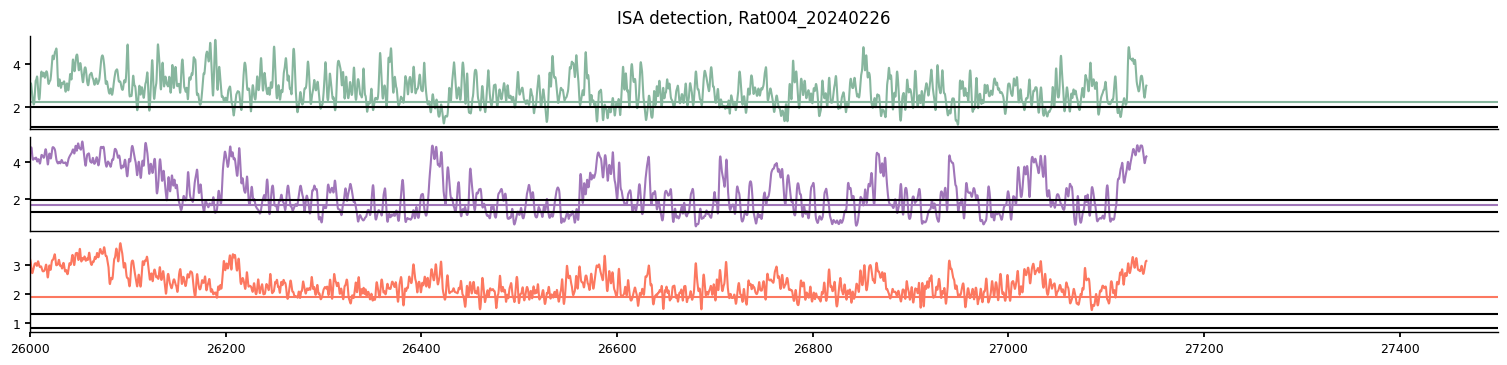

In [8]:
print([f"{fraction['region'][i].item()} {units[i].item()} {f}" for i, f in enumerate(fraction.values)])
start = 26000
stop = start + 1500
fig, ax = fma.plotting.makeFigure(f'ISA detection, {fraction.base.values}',[len(fraction['region']),1],size=[38,len(fraction['region'])*3])
for i, r in enumerate(fraction['region'].values):
    fma.plotting.plotXY(fr[:,[0,1+i]],start,stop,color=isru.paperColors(r),ax=ax[i])
    ax[i].axhline(thresh_data[0].sel(region=r),color=isru.paperColors(r))
    ax[i].axhline(thresh_data[1].sel(region=r),color='k')
    ax[i].axhline(thresh_data[2].sel(region=r),color='k')
    fma.plotting.plotIntervals(isr_dict[r],ax=ax[i])
    fma.plotting.plotIntervals(isr_excl_dict[r],color='r',ax=ax[i])
    ax[i].set_xlim([start,stop])
fma.plotting.setProp(ax[:-1],xticks=[]);

run batch

In [5]:
fraction, isr_dict, on_dict, isr_excl_dict, fr, thresh_data, units = fma.data.runBatch(batch_file,_infraSlowIntervals,kwargs={'when': 'sleep.*','threshold': threshold, 'save': True},parallel=True)
# concatenate sessions
fraction_cat = xr.concat([d for d in fraction if d is not None],dim='rat',join='outer') # (session, region, threshold)
# average per animal
fraction_avg = fraction_cat.groupby('rat').mean(dim='rat',skipna=True)
regs = ['nr','th','hpc','lvHPC','rvHPC','ldHPC','rdHPC','pfc','lvmPFC','rvmPFC','ldmPFC','rdmPFC','v1','lAMY','rAMY']


Starting Batch, 2026-06-20 12:44:02.871621 

drift detected in Rat401-20190616 lAMY, phase 0 , drift ratio: 0.18409664160163294
drift detected in Rat399-20190402 rvHPC, phase 0 , drift ratio: 0.5666582657947395
drift detected in Rat012_2025-12-10 pfc, phase 0 , drift ratio: 1.657252998175617
drift detected in Rat012_2025-12-16 pfc, phase 0 , drift ratio: 0.0
drift detected in Rat401-20190616 lAMY, phase 2 , drift ratio: inf
drift detected in Rat401-20190616 rAMY, phase 2 , drift ratio: inf
drift detected in Rat401-20190616 lvmPFC, phase 2 , drift ratio: inf
drift detected in Rat012_2025-12-17 pfc, phase 0 , drift ratio: 0.0
Batch completed with 0 errors, 2026-06-20 12:44:57.009600


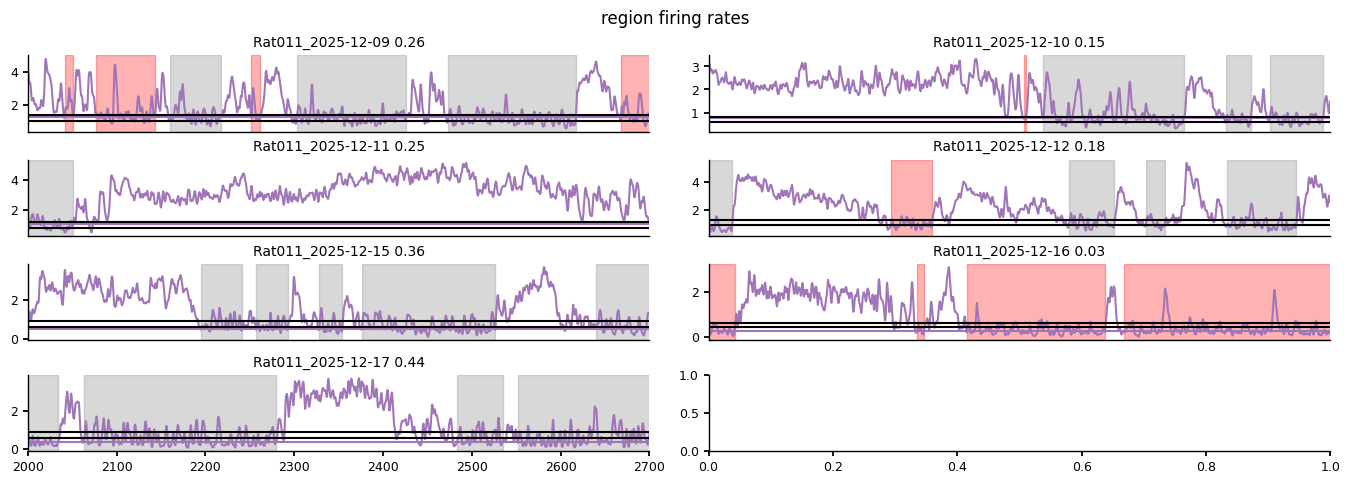

In [6]:
# see NR results
start = np.array([3000,000,2000,2000,2700,4000,2000,2000,1800,3000,2000,2000])
stop = start + 700
rat = 11
sessions = np.where(fraction_cat['rat']==rat)[0][::]
fig, ax = fma.plotting.makeFigure('region firing rates',[(len(sessions)+1)//2,2],size=[34,3.2*(len(sessions)+1)//2])
for i, s in enumerate(sessions):
        r_ind = int(np.where(fraction[s]['region']=='nr')[0][0])
        a_idx = np.unravel_index(i,ax.shape)
        fma.plotting.plotXY(fr[s][:,[0,1+r_ind]],start[i],stop[i],color=isru.paperColors('nr'),ax=ax[a_idx])
        ax[a_idx].axhline(thresh_data[s][0].sel(region='nr'),color=isru.paperColors('nr'))
        ax[a_idx].axhline(thresh_data[s][1].sel(region='nr'),color='k')
        ax[a_idx].axhline(thresh_data[s][2].sel(region='nr'),color='k')
        fma.plotting.plotIntervals(isr_dict[s]['nr'],ax=ax[a_idx])
        fma.plotting.plotIntervals(isr_excl_dict[s]['nr'],color='r',ax=ax[a_idx])
        ax[a_idx].set_xlim([start[i],stop[i]]), ax[a_idx].set_title(f"{fraction[s]['base'].item()} {fraction[s].sel(region='nr').values:.2f}",fontsize=10)
fma.plotting.setProp(ax[:-1,:],xticks=[]);

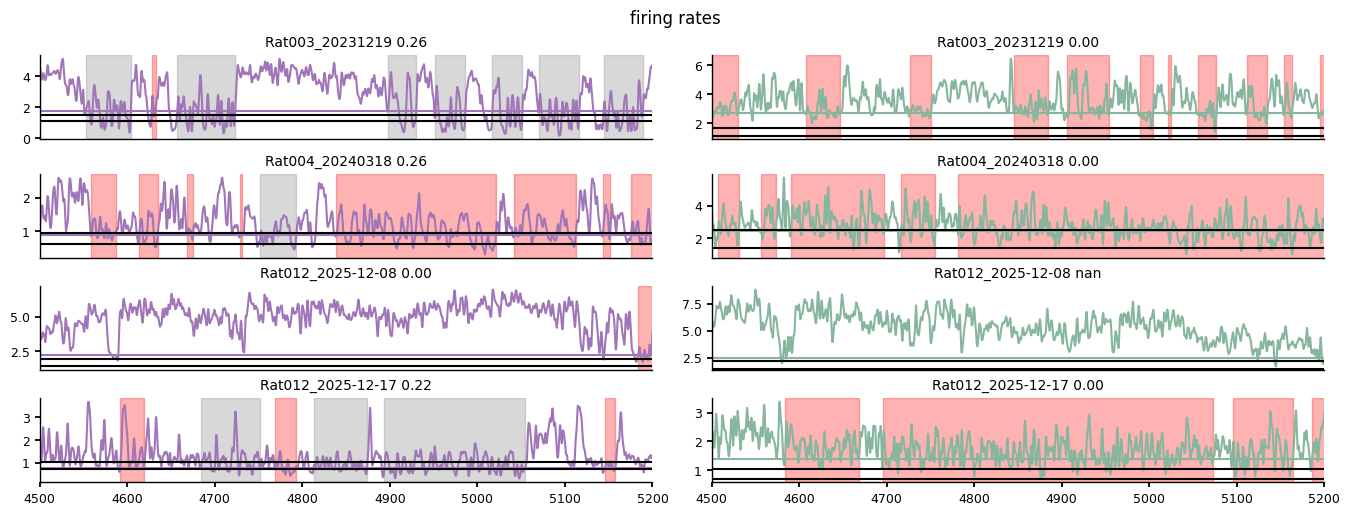

In [7]:
# compare NR and HPC
start = np.array([2000,1500,3000,4500,2000])
stop = start + 700
sessions = [5,29,51,57]
fig, ax = fma.plotting.makeFigure('firing rates',[len(sessions),2],size=[34,3.2*len(sessions)])
for i, s in enumerate(sessions):
    for k, r in enumerate(['nr','hpc']):
        r_ind = int(np.where(fraction[s]['region']==r)[0][0])
        fma.plotting.plotXY(fr[s][:,[0,1+r_ind]],start[i],stop[i],color=isru.paperColors(r),ax=ax[i,k])
        ax[i,k].axhline(thresh_data[s][0].sel(region=r),color=isru.paperColors(r))
        ax[i,k].axhline(thresh_data[s][1].sel(region=r),color='k')
        ax[i,k].axhline(thresh_data[s][2].sel(region=r),color='k')
        fma.plotting.plotIntervals(isr_dict[s][r],ax=ax[i,k])
        fma.plotting.plotIntervals(isr_excl_dict[s][r],color='r',ax=ax[i,k])
        ax[i,k].set_xlim([start[i],stop[i]]), ax[i,k].set_title(f"{fraction[s]['base'].item()} {fraction[s].sel(region=r).values:.2f}",fontsize=10)
fma.plotting.setProp(ax[:-1,:],xticks=[]);

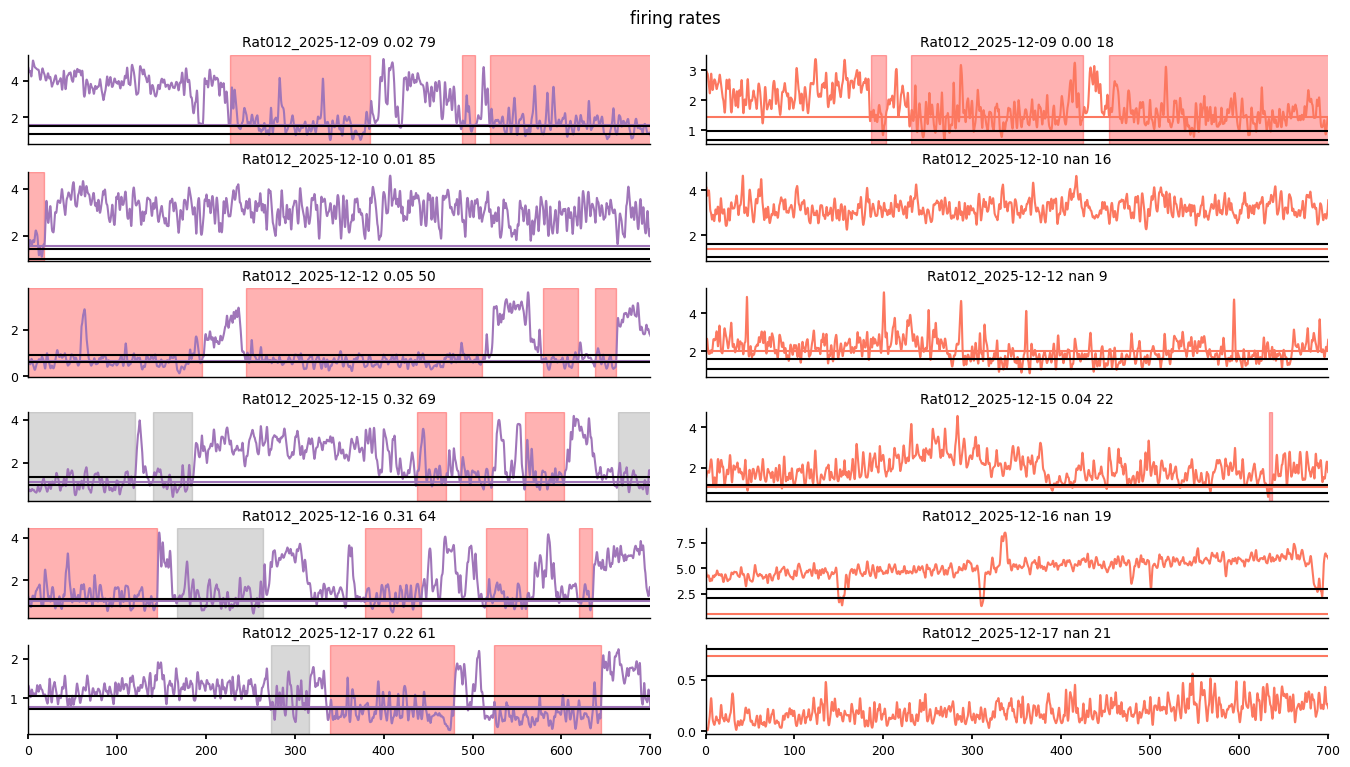

In [8]:
# compare NR and PFC
start = np.array([2000,6000,4000,4000,8000,000])
stop = start + 700
sessions = [52,53,54,55,56,57]
fig, ax = fma.plotting.makeFigure('firing rates',[len(sessions),2],size=[34,3.2*len(sessions)])
for i, s in enumerate(sessions):
    for k, r in enumerate(['nr','pfc']):
        r_ind = int(np.where(fraction[s]['region']==r)[0][0])
        fma.plotting.plotXY(fr[s][:,[0,1+r_ind]],start[i],stop[i],color=isru.paperColors(r),ax=ax[i,k])
        ax[i,k].axhline(thresh_data[s][0].sel(region=r),color=isru.paperColors(r))
        ax[i,k].axhline(thresh_data[s][1].sel(region=r),color='k')
        ax[i,k].axhline(thresh_data[s][2].sel(region=r),color='k')
        fma.plotting.plotIntervals(isr_dict[s][r],ax=ax[i,k])
        fma.plotting.plotIntervals(isr_excl_dict[s][r],color='r',ax=ax[i,k])
        ax[i,k].set_xlim([start[i],stop[i]]), ax[i,k].set_title(f"{fraction[s]['base'].item()} {fraction[s].sel(region=r).values:.2f} {units[s].sel(region=r).values}",fontsize=10)
fma.plotting.setProp(ax[:-1,:],xticks=[]);

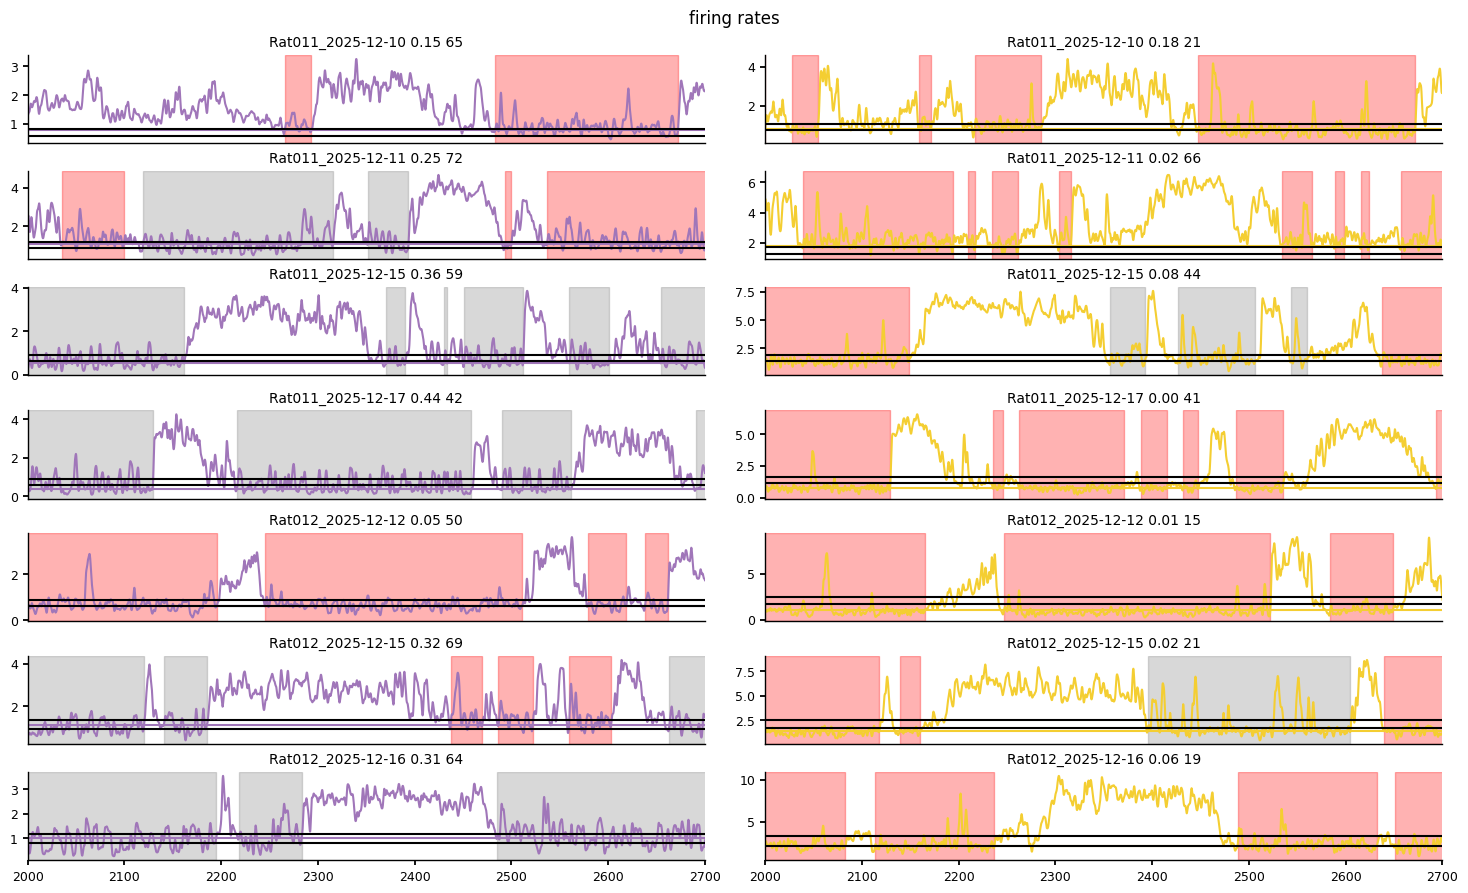

In [16]:
# compare NR and TH
start = np.array([2000,4000,4000,4000,4000,4000,2000,2000])
stop = start + 700
sessions = [44,45,47,49,54,55,56]
fig, ax = fma.plotting.makeFigure('firing rates',[len(sessions),2],size=[37,3.2*len(sessions)])
for i, s in enumerate(sessions):
    for k, r in enumerate(['nr','th']):
        r_ind = int(np.where(fraction[s]['region']==r)[0][0])
        fma.plotting.plotXY(fr[s][:,[0,1+r_ind]],start[i],stop[i],color=isru.paperColors(r),ax=ax[i,k])
        ax[i,k].axhline(thresh_data[s][0].sel(region=r),color=isru.paperColors(r))
        ax[i,k].axhline(thresh_data[s][1].sel(region=r),color='k')
        ax[i,k].axhline(thresh_data[s][2].sel(region=r),color='k')
        fma.plotting.plotIntervals(isr_dict[s][r],ax=ax[i,k])
        fma.plotting.plotIntervals(isr_excl_dict[s][r],color='r',ax=ax[i,k])
        ax[i,k].set_xlim([start[i],stop[i]]), ax[i,k].set_title(f"{fraction[s]['base'].item()} {fraction[s].sel(region=r).values:.2f} {units[s].sel(region=r).values}",fontsize=10)
fma.plotting.setProp(ax[:-1,:],xticks=[]);
do_save and fma.plotting.saveFigure(fig,froot / 'Examples/nr_th_detection',['png','svg'])

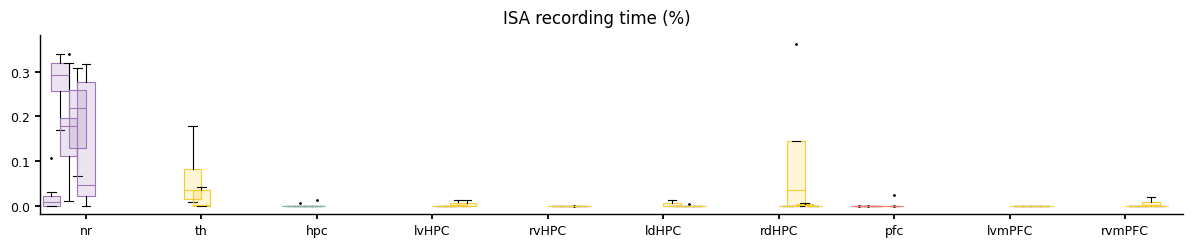

In [6]:
fig, ax = fma.plotting.makeFigure('ISA recording time (%)',size=[30,6])
n_rat = len(np.unique(fraction_cat['rat']))
x = np.linspace(-0.3,0.3,n_rat)
for i, r in enumerate(regs):
    fma.plotting.boxPlot([g for _, g in fraction_cat.sel(region=r).groupby('rat')],x=x+i,color=isru.paperColors(r),ax=ax[0])
ax[0].set_xticks(np.arange(len(regs)),regs); ax[0].set_xlim([-0.4,n_rat+0.5]);

['nr True', 'th True', 'hpc False', 'vhpc False', 'dhpc True', 'npfc True', 'v1 False', 'amy False']


False

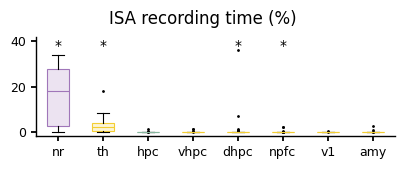

In [8]:
fig, ax = fma.plotting.makeFigure('ISA recording time (%)',size=[10,4])

# group data by region, fusing homotopic regions
data = {str(r): g for r, g in fraction_cat.groupby('region')}
data['amy'] = xr.concat((data['lAMY'].assign_coords(region=['amy']),data['rAMY'].assign_coords(region=['amy'])),dim='rat')
data['npfc'] = xr.concat((data['pfc'].assign_coords(region=['pfc']),data['lvmPFC'].assign_coords(region=['pfc']),data['rvmPFC'].assign_coords(region=['pfc']),
                          data['ldmPFC'].assign_coords(region=['pfc']),data['rdmPFC'].assign_coords(region=['pfc'])),dim='rat')
data['vhpc'] = xr.concat((data['lvHPC'].assign_coords(region=['vhpc']),data['rvHPC'].assign_coords(region=['vhpc'])),dim='rat')
data['dhpc'] = xr.concat((data['ldHPC'].assign_coords(region=['dhpc']),data['rdHPC'].assign_coords(region=['dhpc'])),dim='rat')
regs = ['nr','th','hpc','vhpc','dhpc','npfc','v1','amy']

fma.plotting.boxPlot([data[r]*100 for r in regs],color=isru.paperColors(regs),ax=ax[0])
ax[0].set_xticks(np.arange(1,len(regs)+1),regs)

# test distributions against zero
p_val = []
for r in regs:
    stat, p = sps.wilcoxon(data[r].dropna(dim='rat'),alternative='two-sided')
    p_val.append(p[0])
reject, pvals_fdr, _, _ = smsm.multipletests(p_val,alpha=0.05,method='fdr_bh')
print([f'{regs[i]} {p}' for i, p in enumerate(reject)])

# plot significance
y_lim = ax[0].get_ylim()
for i, r in enumerate(reject):
    if r:
        ax[0].text(i+1,y_lim[1],'*',ha='center',va='center',color='k',size=None)
ax[0].set_ylim([y_lim[0],y_lim[1]*1.1])
do_save and fma.plotting.saveFigure(fig,froot / 'detection',['png','svg'])

Are first blinky sessions maybe not in NR?? MUST CHECKKK